# Ejemplo de aplicación de K-Means con el dataset Wine de scikit-learn

## Objetivos
En este notebook utilizaremos el dataset **Wine** de `scikit-learn` para:
1. cargar y explorar los datos;
2. revisar calidad, escalas y distribución de las variables;
3. preprocesar las características;
4. aplicar K-Means;
5. seleccionar \(k\) con inercia y Silhouette;
6. interpretar los clusters;
7. comparar al final con las clases reales.

> Las etiquetas reales no se usan para construir los clusters; se reservan para evaluación externa.


## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

pd.set_option("display.max_columns", None)


## 2. Carga del dataset

`load_wine()` contiene 178 muestras, 13 características químicas numéricas y tres clases correspondientes a cultivares.

Durante el clustering trabajaremos únicamente con `X`.


In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dimensiones de X:", X.shape)
print("Número de clases reales:", y.nunique())
X.head()


Dimensiones de X: (178, 13)
Número de clases reales: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración inicial

Antes de aplicar clustering revisaremos:
- tipos de datos;
- valores faltantes;
- estadísticos descriptivos;
- escalas;
- posibles valores atípicos;
- correlaciones.

Esto es importante porque K-Means depende de las distancias entre observaciones.


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
# Valores faltantes
X.isna().sum()


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [5]:
# Estadísticos descriptivos
X.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.1. Comparación de escalas

In [6]:
ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "rango": X.max() - X.min(),
    "media": X.mean(),
    "std": X.std()
}).sort_values("rango", ascending=False)

ranges


,min,max,rango,media,std
proline,278.00,1680.00,1402.00,746.893258,314.907474
magnesium,70.00,162.00,92.00,99.741573,14.282484
alcalinity_of_ash,10.60,30.00,19.40,19.494944,3.339564
color_intensity,1.28,13.00,11.72,5.058090,2.318286
malic_acid,0.74,5.80,5.06,2.336348,1.117146
flavanoids,0.34,5.08,4.74,2.029270,0.998859
alcohol,11.03,14.83,3.80,13.000618,0.811827
proanthocyanins,0.41,3.58,3.17,1.590899,0.572359
total_phenols,0.98,3.88,2.90,2.295112,0.625851
od280/od315_of_diluted_wines,1.27,4.00,2.73,2.611685,0.709990


Observe si algunas variables presentan rangos mucho mayores que otras.  
Si aplicáramos K-Means directamente, esas variables podrían dominar la distancia euclidiana.


### 3.2. Histogramas

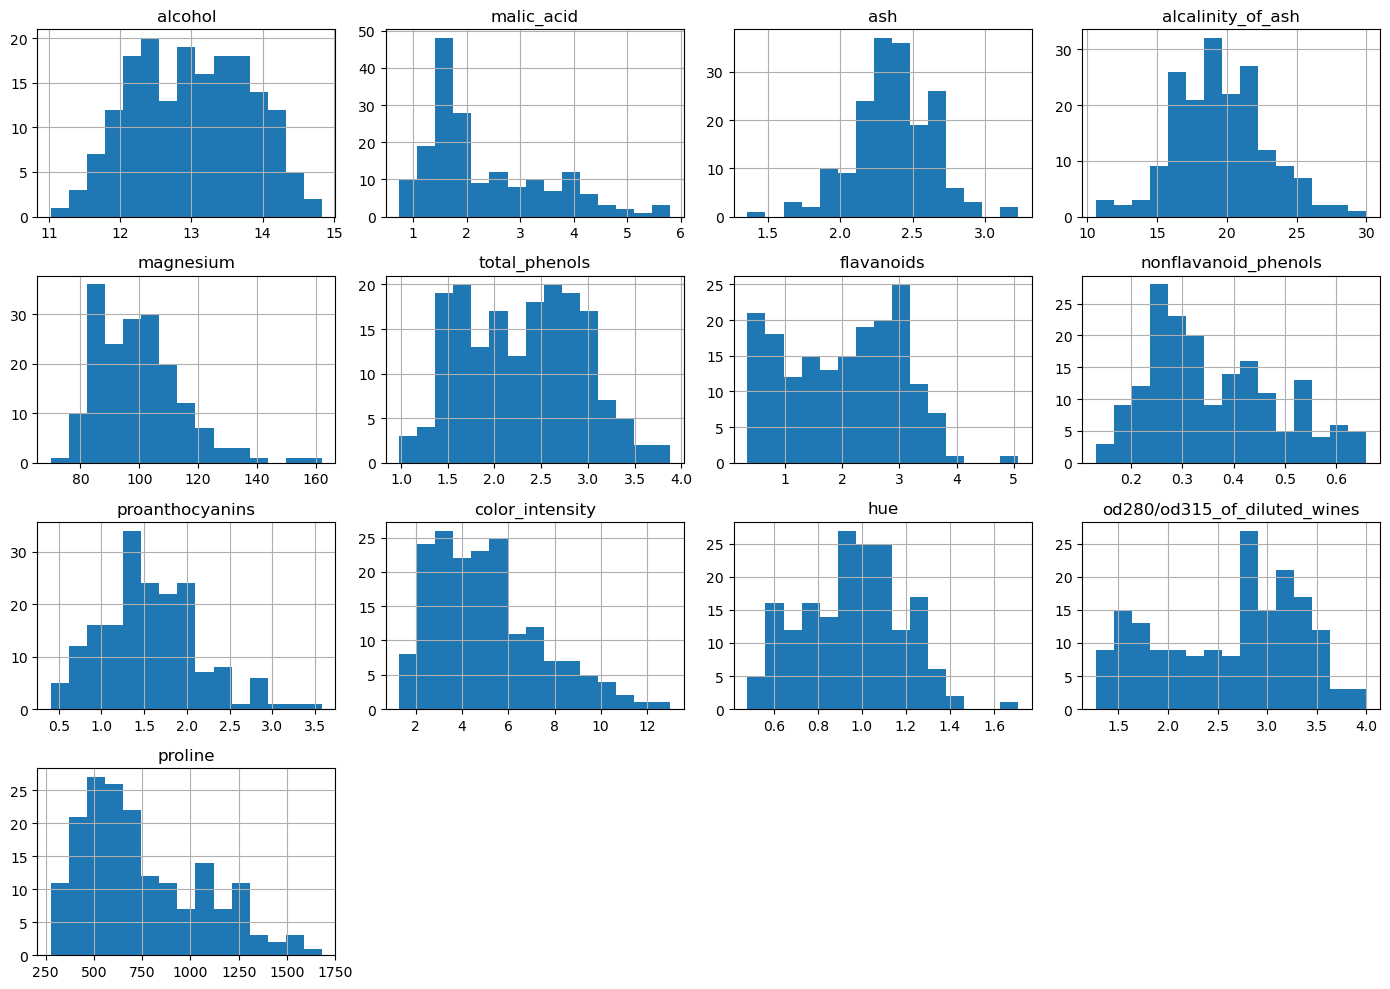

In [7]:
X.hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()


### 3.3. Boxplots

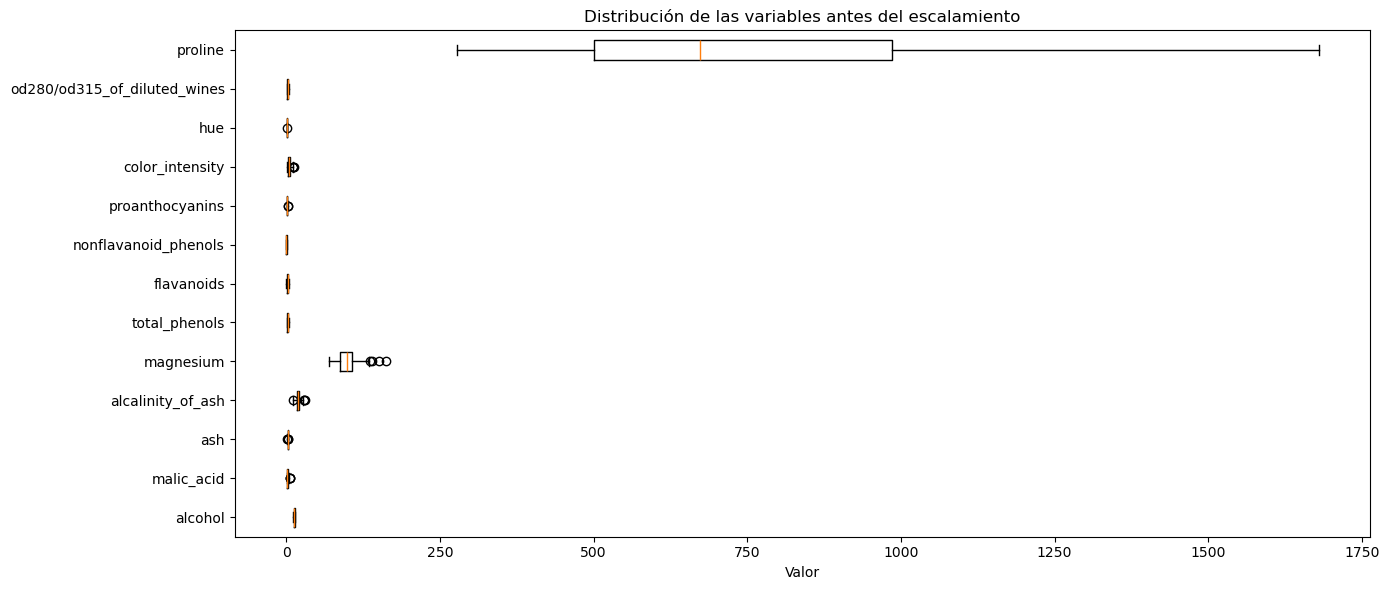

In [8]:
plt.figure(figsize=(14, 6))
plt.boxplot(X.values, tick_labels=X.columns, vert=False)
plt.xlabel("Valor")
plt.title("Distribución de las variables antes del escalamiento")
plt.tight_layout()
plt.show()


### 3.4. Matriz de correlación

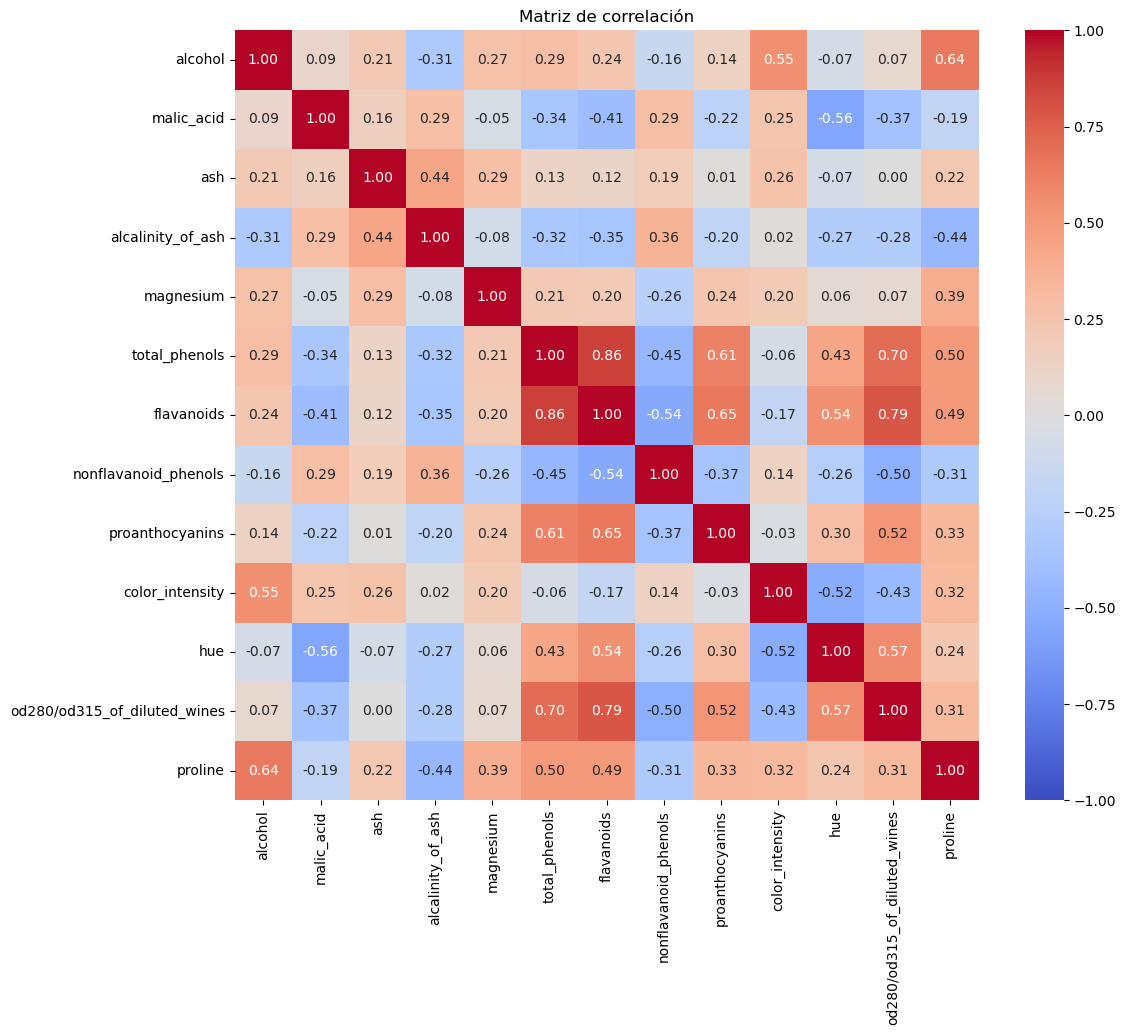

In [14]:
import seaborn as sns

corr = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()


## 4. Preprocesamiento

K-Means minimiza la suma de distancias cuadradas de las observaciones a sus centroides. Como las variables tienen escalas diferentes, aplicaremos `StandardScaler`.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


### 4.1. Inspección después del escalamiento

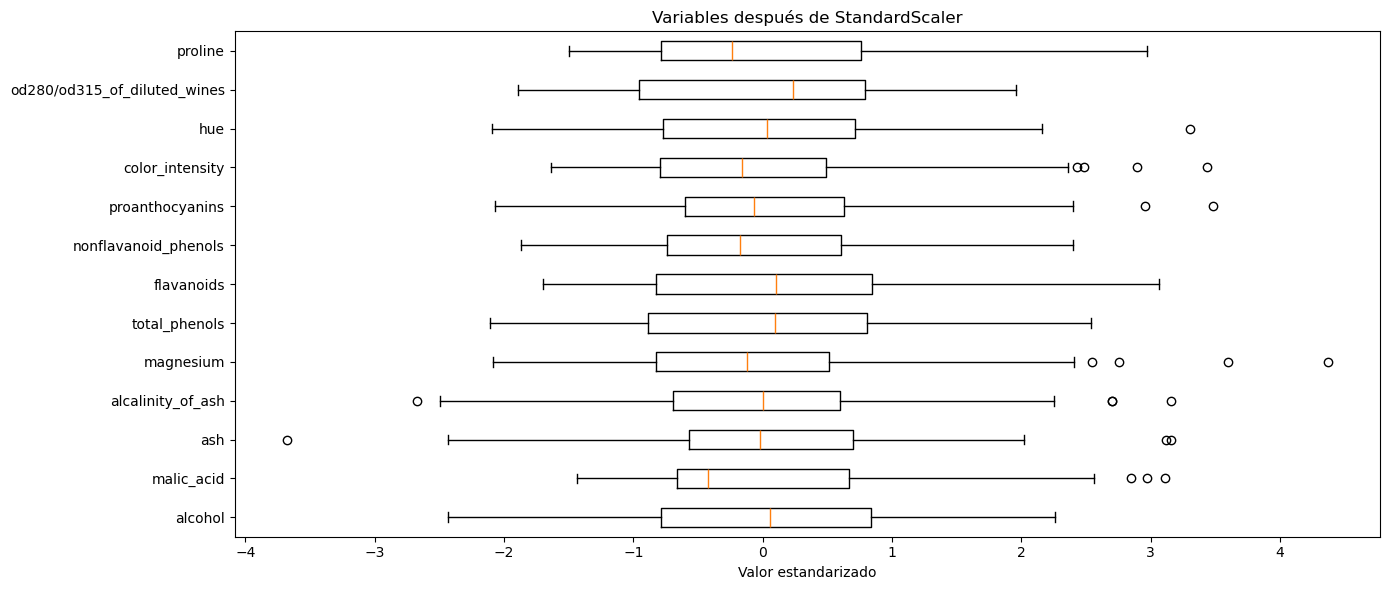

In [12]:
plt.figure(figsize=(14, 6))
plt.boxplot(X_scaled, tick_labels=X.columns, vert=False)
plt.xlabel("Valor estandarizado")
plt.title("Variables después de StandardScaler")
plt.tight_layout()
plt.show()


## 5. Primera aplicación de K-Means con \(k=3\)

Usaremos:
- `init="k-means++"`;
- `n_init=20`;
- `random_state=42`.


In [22]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

print("Inercia final:", kmeans.inertia_)
print("\nTamaño de los clusters:")
print(pd.Series(clusters).value_counts().sort_index())


Inercia final: 1277.9284888446423

Tamaño de los clusters:
0    65
1    51
2    62
Name: count, dtype: int64


C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-means++ es una variante de K-means clásico, el cual perfecciona la inicialización de los K primeros centroides. El mecanismo consiste en seleccionar centroides iniciales distantes entre sí, utiliza la distancia para sesgar aleatoriamente la selección hacia puntos alejados de los centroides ya escogidos.

El parámetro n_init=20 significa que K-Means se ejecutará 20 veces con distintas inicializaciones de centroides y conservará la solución con menor inercia.


## 6. Visualización con PCA

El clustering se realizó con las 13 variables estandarizadas.  
PCA se utiliza aquí solo para proyectar los datos a dos dimensiones y visualizar los grupos.


Varianza explicada por PC1 + PC2: 0.554


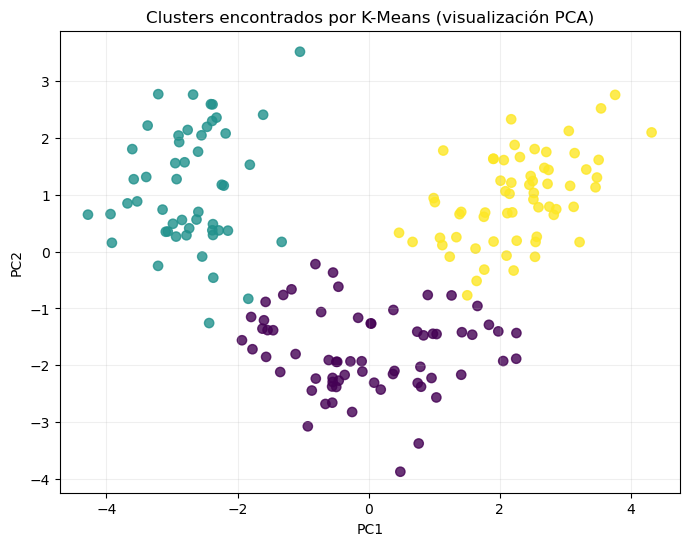

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 + PC2:",
      round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=45, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters encontrados por K-Means (visualización PCA)")
plt.grid(alpha=0.2)
plt.show()


## 7. Selección del número de clusters

Analizaremos el clustering mediante Inercia y Silhouette

In [24]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "k": list(k_values),
    "inercia": inertias,
    "silhouette": silhouettes
})

results


C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

,k,inercia,silhouette
0,2,1658.758852,0.259317
1,3,1277.928489,0.284859
2,4,1175.351881,0.258608
3,5,1107.007343,0.231528
4,6,1046.002333,0.237167
5,7,981.595233,0.203628
6,8,935.201211,0.157014
7,9,889.892911,0.149882
8,10,845.895237,0.143638


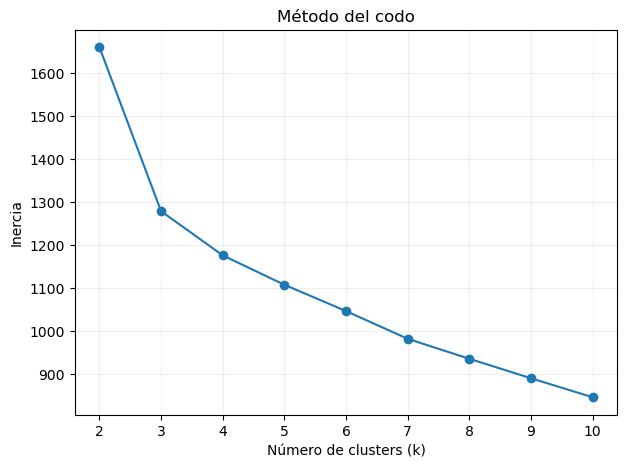

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(results["k"], results["inercia"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(alpha=0.2)
plt.show()


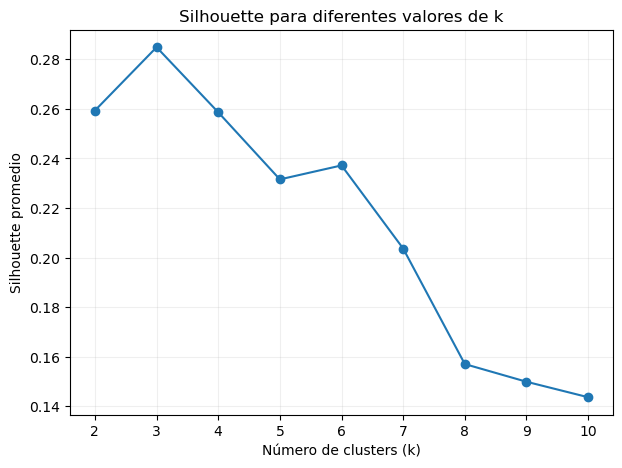

Mejor k según Silhouette: 3


In [26]:
plt.figure(figsize=(7, 5))
plt.plot(results["k"], results["silhouette"], marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette promedio")
plt.title("Silhouette para diferentes valores de k")
plt.grid(alpha=0.2)
plt.show()

best_k_sil = int(results.loc[results["silhouette"].idxmax(), "k"])
print("Mejor k según Silhouette:", best_k_sil)


### Preguntas de análisis
1. ¿Se observa claramente un codo en la gráfica de inercia?
2. ¿Qué valor de \(k\) maximiza Silhouette?
3. ¿Ambos criterios sugieren el mismo número de clusters?
4. ¿Por qué no basta con escoger el \(k\) con menor inercia?


## 8. Interpretación de los clusters

Analizaremos las medias de las variables dentro de cada grupo.


In [27]:
X_with_cluster = X.copy()
X_with_cluster["cluster"] = clusters

cluster_profiles = X_with_cluster.groupby("cluster").mean()
cluster_profiles


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


También podemos analizar los perfiles estandarizados para identificar variables por encima o por debajo de la media global.


In [28]:
scaled_profiles = (
    pd.DataFrame(X_scaled, columns=X.columns)
    .assign(cluster=clusters)
    .groupby("cluster")
    .mean()
)

scaled_profiles.T


cluster,0,1,2
alcohol,-0.926072,0.164907,0.835232
malic_acid,-0.394042,0.871547,-0.303810
ash,-0.494517,0.186898,0.364706
alcalinity_of_ash,0.170602,0.524367,-0.610191
magnesium,-0.491712,-0.075473,0.577587
total_phenols,-0.075983,-0.979330,0.885237
flavanoids,0.020813,-1.215248,0.977820
nonflavanoid_phenols,-0.033534,0.726064,-0.562090
proanthocyanins,0.058266,-0.779706,0.580287
color_intensity,-0.901914,0.941539,0.171063


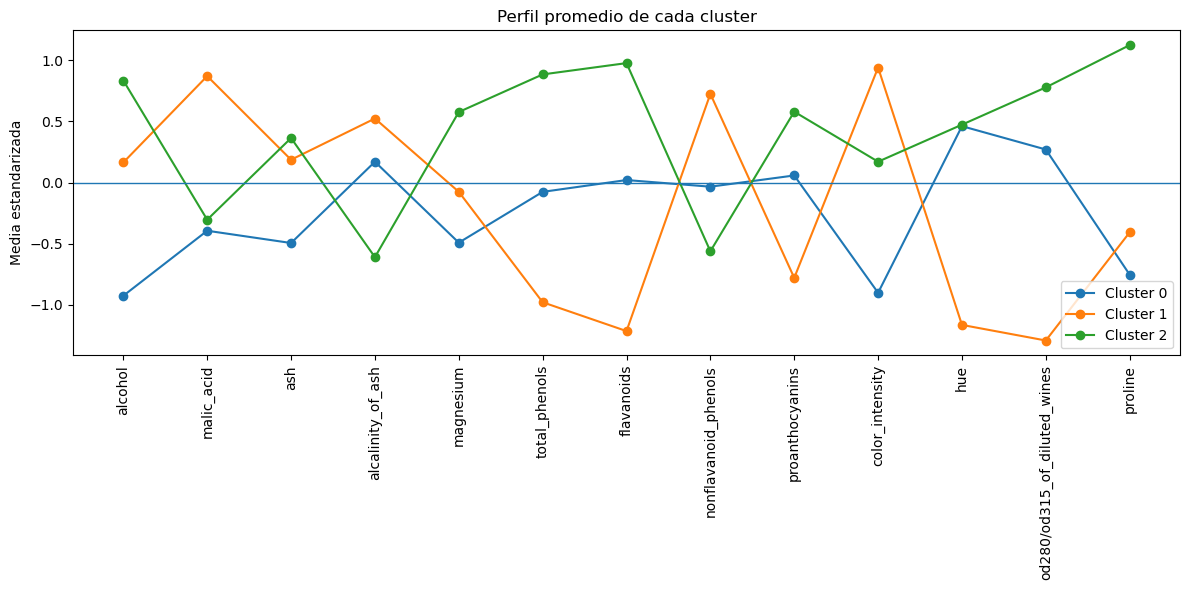

In [29]:
plt.figure(figsize=(12, 6))

for cluster_id in scaled_profiles.index:
    plt.plot(
        scaled_profiles.columns,
        scaled_profiles.loc[cluster_id],
        marker="o",
        label=f"Cluster {cluster_id}"
    )

plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Media estandarizada")
plt.title("Perfil promedio de cada cluster")
plt.legend()
plt.tight_layout()
plt.show()
